In [1]:
import pandas as pd


In [2]:
df=pd.read_csv("landslide.csv")
df["place"] = df["place"].str.strip().str.title()
df.drop(df[df["place"] == "Idukki"].index, inplace=True)

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


X = df[["month", "rainfall_mm", "elevation_m", "slope_deg", "soil_type"]].copy()
y = df["landslide"]

In [4]:
le = LabelEncoder()
X["soil_type"] = le.fit_transform(X["soil_type"])
df["soil_type"] = le.transform(df["soil_type"])

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



In [6]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [7]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print(classification_report(y_test, y_pred))

Accuracy: 0.7247474747474747
              precision    recall  f1-score   support

           0       0.76      0.88      0.81       270
           1       0.60      0.39      0.47       126

    accuracy                           0.72       396
   macro avg       0.68      0.64      0.64       396
weighted avg       0.71      0.72      0.71       396



In [8]:
place_info = (
    df.groupby("place")[["elevation_m", "slope_deg", "soil_type"]]
      .first()
      .reset_index()
)

In [9]:
monthly_avg_rainfall = (
    df.groupby(["place", "month"])["rainfall_mm"]
      .mean()
      .reset_index()
)

In [10]:
# sample = pd.DataFrame([{
#     "month": 8,
#     "rainfall_mm": 700,
#     "elevation_m": 900,
#     "slope_deg": 28,
#     "soil_type": le.transform(["laterite"])[0]
# }])

# prob = model.predict_proba(sample)[0][1]
# print("Landslide risk probability:", prob)

In [11]:
from datetime import datetime

In [12]:
import calendar

In [13]:
feature_columns = ["month","rainfall_mm", "elevation_m", "slope_deg"]

In [14]:
def predict_landslide_monthly(place, month):

    data = df[
        (df["place"] == place) &
        (df["month"] == month)
    ]

    if data.empty:
        raise ValueError("No landslide data")

    means = data[["rainfall_mm", "elevation_m", "slope_deg", "soil_type"]].mean()

    features = pd.DataFrame([{
        "month": month,
        "rainfall_mm": means["rainfall_mm"],
        "elevation_m": means["elevation_m"],
        "slope_deg": means["slope_deg"],
        "soil_type": means["soil_type"]
    }])

    prob = model.predict_proba(features)[0][1]

    return {
        "probability": round(float(prob), 2),
        "level": risk_level(prob)
    }

In [15]:
def risk_level(prob):
    if prob < 0.3:
        return "LOW"
    elif prob < 0.6:
        return "MODERATE"
    else:
        return "HIGH"

In [16]:
def get_user_output(place, date_str):
    prob = predict_landslide_risk(place, date_str)
    level = risk_level(prob)

    explanation = (
        f"For {place} in {date_str[:7]}, the estimated landslide risk is {level} "
        f"({prob*100:.1f}%). This assessment is based on historical rainfall patterns "
        f"and terrain characteristics such as slope and elevation."
    )

    return {
        "place": place,
        "date": date_str,
        "risk_probability": round(prob, 2),
        "risk_level": level,
        "explanation": explanation
    }

In [17]:
# ==============================
# FLOOD MODEL SECTION (FIXED)
# ==============================

df_flood_raw = pd.read_csv("flood.csv")

df_flood_raw["place"] = df_flood_raw["place"].str.strip().str.title()

In [18]:
df_flood = df_flood_raw.copy()

flood_feature_cols = [
    "month",
    "rainfall_mm",
    "rainfall_3day",
    "temperature_c",
    "humidity_percent",
    "elevation_m",
    "slope_deg",
    "soil_type"
]

X_flood = df_flood[flood_feature_cols].copy()
y_flood = df_flood["flood"]

In [19]:
from sklearn.preprocessing import LabelEncoder

le_soil_flood = LabelEncoder()
X_flood["soil_type"] = le_soil_flood.fit_transform(X_flood["soil_type"])

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV


Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_flood,
    y_flood,
    test_size=0.2,
    random_state=42,
    stratify=y_flood
)

base_rf = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10, 
    min_samples_leaf=5, 
    random_state=42
)
flood_model = CalibratedClassifierCV(base_rf, method='sigmoid', cv=5)
flood_model.fit(Xf_train, yf_train)

,estimator,RandomForestC...ndom_state=42)
,method,'sigmoid'
,cv,5
,n_jobs,None
,ensemble,'auto'
,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0


In [21]:
def predict_flood_monthly(place, month):

    # Filter using RAW dataframe (string works)
    data = df_flood_raw[
        (df_flood_raw["place"] == place) &
        (df_flood_raw["month"] == month)
    ]

    if data.empty:
        return None

    # Numeric mean
    numeric_means = data[
        ["rainfall_mm", "rainfall_3day", "temperature_c",
         "humidity_percent", "elevation_m", "slope_deg"]
    ].mean()

    # Categorical mode (NOT mean)
    soil_mode = data["soil_type"].mode()[0]
    soil_encoded = le_soil_flood.transform([soil_mode])[0]

    # Build feature row
    features = pd.DataFrame([{
        "month": month,
        "rainfall_mm": numeric_means["rainfall_mm"],
        "rainfall_3day": numeric_means["rainfall_3day"],
        "temperature_c": numeric_means["temperature_c"],
        "humidity_percent": numeric_means["humidity_percent"],
        "elevation_m": numeric_means["elevation_m"],
        "slope_deg": numeric_means["slope_deg"],
        "soil_type": soil_encoded
    }])

    prob = flood_model.predict_proba(features)[0][1]
    
    return {
        "probability": round(float(prob), 3),
        "level": risk_level(prob)
    }

In [22]:
predict_flood_monthly("Munnar", 9)

{'probability': 0.03, 'level': 'LOW'}

In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Load
df_thunder = pd.read_csv("thunderstorm.csv")

print(df_thunder.columns.tolist())

# Standardize column names
# Features (daily dynamic only)
thunder_features = [
    "2m_temperature",
    "2m_dewpoint_temperature",
    "surface_pressure",
    "10m_wind_speed",
    "total_precipitation",
    "cape"
]

X = df_thunder[thunder_features]
y = df_thunder["thunderstorm"]

# Split
Xt_train, Xt_test, yt_train, yt_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Model
thunder_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=3,
    class_weight={0:1, 1:2},
    random_state=42
)

thunder_model.fit(Xt_train, yt_train)

# Evaluate
preds = thunder_model.predict(Xt_test)
print(classification_report(yt_test, preds))
df_thunder["place"].unique()

['Unnamed: 0', 'place', 'year', 'month', 'day', '2m_temperature', '10m_wind_speed', 'total_precipitation', '2m_dewpoint_temperature', 'surface_pressure', 'cape', 'thunderstorm']
              precision    recall  f1-score   support

           0       0.93      0.88      0.90      2837
           1       0.63      0.76      0.69       771

    accuracy                           0.85      3608
   macro avg       0.78      0.82      0.80      3608
weighted avg       0.87      0.85      0.86      3608



array(['Kolkata', 'Chennai', 'Mumbai', 'Visakhapatnam',
       'Thiruvananthapuram', 'Patna', 'Guwahati', 'Shillong', 'Ranchi',
       'Bhubaneswar'], dtype=object)

In [24]:
print(y.value_counts(normalize=True))

thunderstorm
0    0.786419
1    0.213581
Name: proportion, dtype: float64


In [25]:
def predict_thunderstorm_day(features_row, threshold=0.4):
    features_df = pd.DataFrame([features_row])
    prob = thunder_model.predict_proba(features_df)[0][1]
    label = 1 if prob >= threshold else 0
    return round(float(prob), 3), label

In [26]:
print("Train accuracy:", thunder_model.score(Xt_train, yt_train))
print("Test accuracy:", thunder_model.score(Xt_test, yt_test))

Train accuracy: 0.928700110864745
Test accuracy: 0.8542128603104213


In [27]:
probs = thunder_model.predict_proba(Xt_test)[:, 1]

for t in [0.3, 0.4, 0.5, 0.6]:
    preds = (probs >= t).astype(int)
    print("Threshold:", t)
    print(classification_report(yt_test, preds))

Threshold: 0.3
              precision    recall  f1-score   support

           0       0.98      0.77      0.86      2837
           1       0.52      0.93      0.67       771

    accuracy                           0.80      3608
   macro avg       0.75      0.85      0.76      3608
weighted avg       0.88      0.80      0.82      3608

Threshold: 0.4
              precision    recall  f1-score   support

           0       0.96      0.82      0.89      2837
           1       0.57      0.87      0.69       771

    accuracy                           0.83      3608
   macro avg       0.77      0.85      0.79      3608
weighted avg       0.88      0.83      0.84      3608

Threshold: 0.5
              precision    recall  f1-score   support

           0       0.93      0.88      0.90      2837
           1       0.63      0.76      0.69       771

    accuracy                           0.85      3608
   macro avg       0.78      0.82      0.80      3608
weighted avg       0.87      

In [28]:
import pandas as pd

importance = pd.Series(
    thunder_model.feature_importances_,
    index=thunder_features
).sort_values(ascending=False)

print(importance)

cape                       0.318537
2m_dewpoint_temperature    0.186100
surface_pressure           0.169813
total_precipitation        0.140289
2m_temperature             0.103886
10m_wind_speed             0.081375
dtype: float64


In [29]:
# =====================================
# WINDSTORM MODEL SECTION (MONTHLY)
# =====================================

df_wind = pd.read_csv("windstorm.csv")

df_wind.rename(columns={
    "Month": "month",
    "Place": "place"
}, inplace=True)

wind_features = [
    "month",
    "WindSpeed_km_per_hr",
    "Temperature_C",
    "Humidity_percent",
    "WindSpeed_3day_cum"
]

X_wind = df_wind[wind_features].copy()
y_wind = df_wind["Wind_Disaster_Occurred"]

In [30]:
from sklearn.model_selection import train_test_split

Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    X_wind,
    y_wind,
    test_size=0.2,
    random_state=42,
    stratify=y_wind
)

In [31]:
from sklearn.ensemble import RandomForestClassifier

wind_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

wind_model.fit(Xw_train, yw_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [32]:
from sklearn.metrics import classification_report, accuracy_score

yw_pred = wind_model.predict(Xw_test)

print("Windstorm Accuracy:", accuracy_score(yw_test, yw_pred))
print(classification_report(yw_test, yw_pred))

Windstorm Accuracy: 0.6388888888888888
              precision    recall  f1-score   support

           0       0.68      0.76      0.72       131
           1       0.55      0.46      0.50        85

    accuracy                           0.64       216
   macro avg       0.62      0.61      0.61       216
weighted avg       0.63      0.64      0.63       216



In [33]:
def predict_windstorm_monthly(place, month):

    data = df_wind[
        (df_wind["place"] == place) &
        (df_wind["month"] == month)
    ]

    if data.empty:
        return None

    means = data[wind_features].mean()

    features = pd.DataFrame([{
        "month": month,
        "WindSpeed_km_per_hr": means["WindSpeed_km_per_hr"],
        "Temperature_C": means["Temperature_C"],
        "Humidity_percent": means["Humidity_percent"],
        "WindSpeed_3day_cum": means["WindSpeed_3day_cum"]
    }])

    prob = wind_model.predict_proba(features)[0][1]

    # soften extreme confidence
    prob = 0.85 * prob + 0.075

    return {
        "probability": round(float(prob), 2),
        "level": risk_level(prob)
    }

In [34]:
print(df_wind["Wind_Disaster_Occurred"].value_counts())

Wind_Disaster_Occurred
0    654
1    426
Name: count, dtype: int64


In [35]:
print(df_wind.groupby("Wind_Disaster_Occurred")[[
    "WindSpeed_km_per_hr",
    "WindSpeed_3day_cum"
]].mean())

                        WindSpeed_km_per_hr  WindSpeed_3day_cum
Wind_Disaster_Occurred                                         
0                                 39.406697          121.790566
1                                 55.511808          171.968991


In [36]:
def risk_level(prob):
    if prob < 0.3:
        return "LOW"
    elif prob < 0.6:
        return "MODERATE"
    else:
        return "HIGH"

In [37]:
def predict_monthly_all(place, month):

    result = {
        "place": place,
        "month": month
    }

    # Landslide
    try:
        result["landslide"] = predict_landslide_monthly(place, month)
    except:
        result["landslide"] = None

    # Flood
    try:
        result["flood"] = predict_flood_monthly(place, month)
    except:
        result["flood"] = None

    # Windstorm
    try:
        result["windstorm"] = predict_windstorm_monthly(place, month)
    except:
        result["windstorm"] = None

    return result

In [38]:
region_map = {
    # South
    "Kerala": "South",
    "Tamil Nadu": "South",
    "Karnataka": "South",
    "Andhra Pradesh": "South",
    "Telangana": "South",

    # North
    "Uttarakhand": "North",
    "Himachal Pradesh": "North",
    "Punjab": "North",
    "Haryana": "North",
    "Delhi": "North",
    # North
    "Jammu and Kashmir": "North",
    "Uttar Pradesh": "North",

    # West
    "Maharashtra": "West",
    "Gujarat": "West",
    "Rajasthan": "West",
    "Goa": "West",

    # East
    "West Bengal": "East",
    "Odisha": "East",
    "Bihar": "East",
    "Jharkhand": "East",

    # Northeast
    "Sikkim": "Northeast",
    "Meghalaya": "Northeast",
    "Assam": "Northeast",
    "Manipur": "Northeast",
    "Nagaland": "Northeast",
    "Tripura": "Northeast",
    "Mizoram": "Northeast",
    "Arunachal Pradesh": "Northeast"
}

df["region"] = df["state"].map(region_map)
df_flood["region"] = df_flood["state"].map(region_map)

unmapped = pd.concat([
    df[df["region"].isna()]["state"],
    df_flood[df_flood["region"].isna()]["state"]
]).unique()

if len(unmapped) > 0:
    print("WARNING: Unmapped states found:", unmapped)


In [39]:
df_all_locations = pd.concat(
    [
        df[["region", "state", "place"]],
        df_flood[["region", "state", "place"]]
    ]
).drop_duplicates()

In [40]:
def get_regions():
    return sorted(df_all_locations["region"].dropna().unique())
    
def get_states(region):
    return sorted(df_all_locations[df_all_locations["region"] == region]["state"].unique())

def get_places(state):
    return sorted(df_all_locations[df_all_locations["state"] == state]["place"].unique())

In [41]:
def interactive_location_selection():
    
    # ---- Step 1: Show Regions ----
    regions = get_regions()
    print("Available Regions:")
    for i, r in enumerate(regions, 1):
        print(f"{i}. {r}")
    
    region_choice = int(input("Select region number: "))
    selected_region = regions[region_choice - 1]
    
    
    # ---- Step 2: Show States ----
    states = get_states(selected_region)
    print("\nAvailable States:")
    for i, s in enumerate(states, 1):
        print(f"{i}. {s}")
    
    state_choice = int(input("Select state number: "))
    selected_state = states[state_choice - 1]
    
    
    # ---- Step 3: Show Places ----
    places = get_places(selected_state)
    print("\nAvailable Places:")
    for i, p in enumerate(places, 1):
        print(f"{i}. {p}")
    
    place_choice = int(input("Select place number: "))
    selected_place = places[place_choice - 1]
    
    
    return selected_region, selected_state, selected_place

In [42]:
region, state, place = interactive_location_selection()

print("\nYou selected:")
print("Region:", region)
print("State:", state)
print("Place:", place)

Available Regions:
1. East
2. North
3. Northeast
4. South
5. West


Select region number:  5



Available States:
1. Goa
2. Maharashtra
3. Rajasthan


Select state number:  2



Available Places:
1. Mumbai


Select place number:  1



You selected:
Region: West
State: Maharashtra
Place: Mumbai


In [82]:
import ipywidgets as widgets
from IPython.display import display


In [89]:
def date_prediction_widget(place):
    
    # Create dropdowns
    # year_dropdown = widgets.Dropdown(
    #     options=list(range(2020, 2031)),
    #     description='Year:'
    # )

    month_dropdown = widgets.Dropdown(
        options=list(range(1, 13)),
        description='Month:'
    )

    # day_dropdown = widgets.Dropdown(
    #     options=list(range(1, 32)),
    #     description='Day:'
    # )

    # Create button
    predict_button = widgets.Button(
        description="Predict Risk",
        button_style='success'
    )

    output = widgets.Output()

    # Button click logic
    def on_button_click(b):
        with output:
            output.clear_output()

            try:
                month=month_dropdown.value
                date_obj = datetime(2020, month, 1)
                
               
        
                # date_obj = datetime(
                #     year_dropdown.value,
                #     month_dropdown.value,
                #     day_dropdown.value
                # )
                
            # STEP 1: Get prediction
                month = month_dropdown.value
                result = predict_monthly_all(place, month)

            # STEP 2: Header
                print("\n" + "="*40)
                print("📅 Monthly Disaster Prediction")
                print("="*40)
                print(f"Place : {result['place']}")
                month_name = calendar.month_name[date_obj.month]
                print(f"Month : {month_name}")
                print("-"*40)

            # STEP 3: Show disasters
                for disaster in ["landslide", "flood", "windstorm"]:

                    data = result.get(disaster)
    
                    if isinstance(data, dict) and data.get("probability") is not None:
                        prob = data["probability"]
                        level = data["level"]
                        print(f"{disaster.capitalize():15}: {prob*100:.1f}% ({level})")
                    else:
                        print(f"{disaster.capitalize():15}: Not Applicable")

            except Exception as e:
                print("Error:", e)

    predict_button.on_click(on_button_click)

    #display(year_dropdown, month_dropdown, day_dropdown, predict_button, output)
    display(month_dropdown, predict_button, output)
   

In [91]:
date_prediction_widget(place)

Dropdown(description='Month:', options=(1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12), value=1)

Button(button_style='success', description='Predict Risk', style=ButtonStyle())

Output()

In [92]:
# ============================
# 16-DAY THUNDERSTORM FORECAST
# ============================

In [93]:
place_coordinates = {
    "Munnar": (10.0889, 77.0595),
    "Wayanad": (11.6854, 76.1320),
    "Coorg": (12.4244, 75.7382),
    "Nilgiris": (11.4102, 76.6950),
    "Darjeeling": (27.0360, 88.2627),
    "Gangtok": (27.3389, 88.6065),
    "Shillong": (25.5788, 91.8933),
    "Guwahati": (26.1445, 91.7362),
    "Srinagar": (34.0837, 74.7973),
    "Chamoli": (30.4042, 79.3319),
    "Pithoragarh": (29.5820, 80.2182),
    "Manali": (32.2432, 77.1892),
    "Shimla": (31.1048, 77.1734),
    "Mussoorie": (30.4598, 78.0644),
    "Thiruvananthapuram": (8.5241, 76.9366),
    "Mumbai": (19.0760, 72.8777),
    "Chennai": (13.0827, 80.2707),
    "Kochi": (9.9312, 76.2673),
    "Kolkata": (22.5726, 88.3639),
    "Varanasi": (25.3176, 82.9739),
    "Panaji": (15.4909, 73.8278),
    "Udaipur": (24.5854, 73.7125),
    "Patna": (25.5941, 85.1376),
    "Visakhapatnam": (17.6868, 83.2185),
    "Ranchi": (23.3441, 85.3096),
    "Bhubaneswar": (20.2961, 85.8245),
    "Puri": (19.8135, 85.8312),
    "Kedarnath": (30.7352, 79.0669),
}

In [94]:
# API landslide 

In [95]:
def get_historical_daily_baseline(df, place, month):
    
    data = df[
        (df["place"] == place) &
        (df["month"] == month)
    ]
    
    historical_month_mean = data["rainfall_mm"].mean()
    
    historical_daily_baseline = historical_month_mean / 30
    
    if historical_daily_baseline == 0:
        historical_daily_baseline = 0.1
        
    return historical_daily_baseline



In [96]:
from datetime import datetime

current_month = datetime.now().month

try:
    result = predict_landslide_monthly(place, current_month)
    base_prob = result["probability"]
    
    print("Place:", place)
    print("Current Month:", current_month)
    print("Monthly Base Probability:", base_prob)

except ValueError as e:
    print("Error:", e)

Error: No landslide data


In [97]:
def adjust_probability(base_prob, api_rainfall, historical_daily_baseline):
    
    ratio = api_rainfall / historical_daily_baseline
    
    if ratio < 0.7:
        adjustment = -0.05
    elif ratio < 1.3:
        adjustment = 0
    elif ratio < 2:
        adjustment = 0.05
    elif ratio < 3:
        adjustment = 0.10
    else:
        adjustment = 0.15

    new_prob = base_prob + adjustment
    new_prob = max(0, min(new_prob, 1))
    
    return new_prob

In [98]:
import requests

def get_16day_rainfall(place):
    
    if place not in place_coordinates:
        raise ValueError("Coordinates not found for selected place.")
    
    lat, lon = place_coordinates[place]
    
    url = (
        "https://api.open-meteo.com/v1/forecast"
        f"?latitude={lat}"
        f"&longitude={lon}"
        "&daily=precipitation_sum"
        "&forecast_days=16"
        "&timezone=auto"
    )
    
    response = requests.get(url)
    data = response.json()
    
    dates = data["daily"]["time"]
    rainfall_raw = data["daily"]["precipitation_sum"]

    rainfall = []
    for r in rainfall_raw:
        if r is None:
            rainfall.append(0.0)
        else:
            rainfall.append(float(r))
    
    return list(zip(dates, rainfall))

In [99]:
api_forecast = get_16day_rainfall(place)

#api_forecast[:10]

In [100]:
from datetime import datetime

daily_results = []

api_forecast = get_16day_rainfall(place)

for date, rain in api_forecast:
    
    month_of_day = datetime.strptime(date, "%Y-%m-%d").month
    
    try:
        baseline = get_historical_daily_baseline(
            df, place, month_of_day
        )
        
        result = predict_landslide_monthly(
            place, month_of_day
        )
        
        base_prob = result["probability"]
        
        adjusted_prob = adjust_probability(
            base_prob, rain, baseline
        )
        
        daily_results.append({
            "date": date,
            "rainfall": rain,
            "probability": round(adjusted_prob, 3),
            "level": risk_level(adjusted_prob)
        })
        
    except ValueError:
        daily_results.append({
            "date": date,
            "rainfall": rain,
            "probability": None,
            "level": "Not Available"
        })

In [101]:
for day in daily_results:
    print(
        f"{day['date']} | "
        f"Rain: {day['rainfall']} mm | "
        f"Landslide Risk: {day['level']} "
        f"({day['probability']})"
    )

2026-03-04 | Rain: 0.0 mm | Landslide Risk: Not Available (None)
2026-03-05 | Rain: 0.0 mm | Landslide Risk: Not Available (None)
2026-03-06 | Rain: 0.0 mm | Landslide Risk: Not Available (None)
2026-03-07 | Rain: 0.0 mm | Landslide Risk: Not Available (None)
2026-03-08 | Rain: 0.0 mm | Landslide Risk: Not Available (None)
2026-03-09 | Rain: 0.0 mm | Landslide Risk: Not Available (None)
2026-03-10 | Rain: 0.0 mm | Landslide Risk: Not Available (None)
2026-03-11 | Rain: 0.0 mm | Landslide Risk: Not Available (None)
2026-03-12 | Rain: 0.0 mm | Landslide Risk: Not Available (None)
2026-03-13 | Rain: 0.0 mm | Landslide Risk: Not Available (None)
2026-03-14 | Rain: 0.0 mm | Landslide Risk: Not Available (None)
2026-03-15 | Rain: 0.0 mm | Landslide Risk: Not Available (None)
2026-03-16 | Rain: 0.0 mm | Landslide Risk: Not Available (None)
2026-03-17 | Rain: 0.0 mm | Landslide Risk: Not Available (None)
2026-03-18 | Rain: 0.0 mm | Landslide Risk: Not Available (None)
2026-03-19 | Rain: 0.0 mm

In [102]:
# print("Base Monthly Probability:", base_prob)
# print("Historical Daily Baseline:", baseline)

In [103]:
# # ---- STRESS TEST (does not affect real pipeline) ----

# test_values = [10, 20, 40, 80, 120]

# print("Base Monthly Probability:", base_prob)
# print("Historical Daily Baseline:", baseline)
# print("-" * 40)

# for rain in test_values:
#     prob = adjust_probability(base_prob, rain, baseline)
#     print(f"Rainfall: {rain} mm -> Adjusted Probability: {round(prob, 3)} | Level: {risk_level(prob)}")
df_flood[["rainfall_mm", "rainfall_3day"]].corr()

,rainfall_mm,rainfall_3day
rainfall_mm,1.00000,0.91838
rainfall_3day,0.91838,1.00000


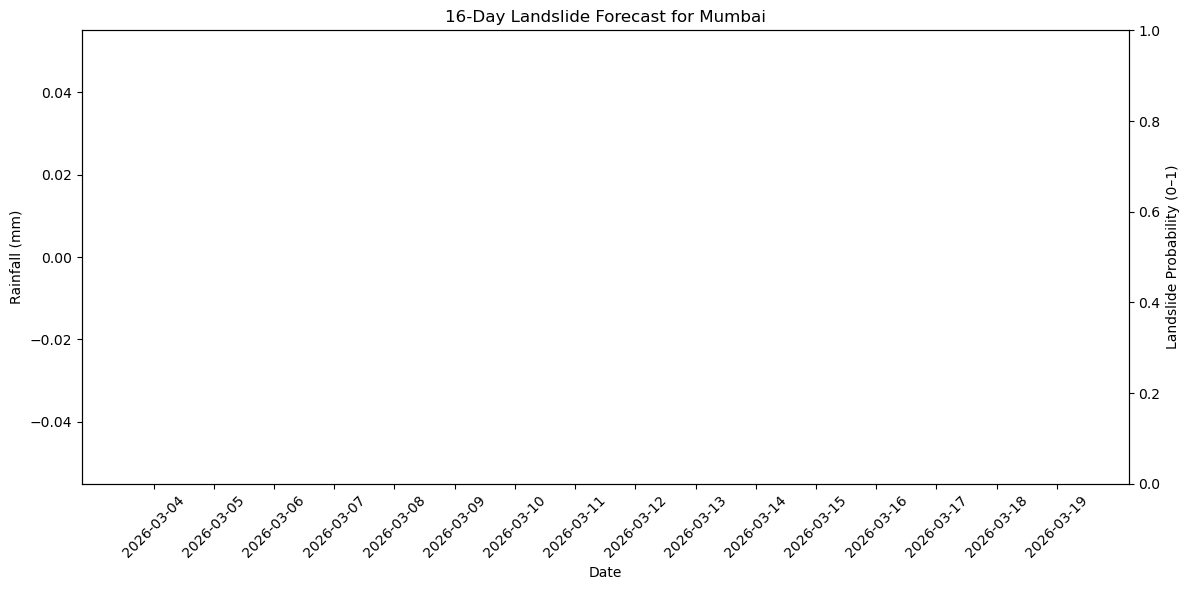

In [104]:
import matplotlib.pyplot as plt

# Extract data
dates = [day["date"] for day in daily_results]
rainfall_values = [day["rainfall"] for day in daily_results]
prob_values = [day["probability"] for day in daily_results]

# Create figure
fig, ax1 = plt.subplots(figsize=(12, 6))

# ---- Rainfall (Bar Chart) ----
ax1.bar(dates, rainfall_values)
ax1.set_ylabel("Rainfall (mm)")
ax1.set_xlabel("Date")
ax1.tick_params(axis='x', rotation=45)

# ---- Probability (Line Chart) ----
ax2 = ax1.twinx()
ax2.plot(dates, prob_values, marker='o')
ax2.set_ylabel("Landslide Probability (0–1)")
ax2.set_ylim(0, 1)  # keep probability scale fixed

# Title
plt.title(f"16-Day Landslide Forecast for {place}")

plt.tight_layout()
plt.show()

In [105]:
#flood api

In [106]:
place_data = df_flood[
    (df_flood["place"] == place) &
    (df_flood["month"] == month_of_day)
]



hist_temp = place_data["temperature_c"].mean()
hist_humidity = place_data["humidity_percent"].mean()

In [107]:
import requests
import numpy as np
import pandas as pd

def get_flood_api_data(place):

    if place not in place_coordinates:
        raise ValueError(f"Coordinates not found for {place}")

    lat, lon = place_coordinates[place]

    url = (
        f"https://api.open-meteo.com/v1/forecast?"
        f"latitude={lat}&longitude={lon}"
        f"&daily=precipitation_sum,temperature_2m_max"
        f"&hourly=relative_humidity_2m"
        f"&forecast_days=16"
        f"&timezone=auto"
    )

    response = requests.get(url)
    data = response.json()

    # -----------------------------
    # Daily Data
    # -----------------------------
    dates = data["daily"]["time"]
    rainfall = data["daily"]["precipitation_sum"]
    temperature = data["daily"]["temperature_2m_max"]

    # -----------------------------
    # Hourly Humidity → Convert to Daily Mean
    # -----------------------------
    hourly_times = data["hourly"]["time"]
    hourly_humidity = data["hourly"]["relative_humidity_2m"]

    df_hourly = pd.DataFrame({
        "time": pd.to_datetime(hourly_times),
        "humidity": hourly_humidity
    })

    df_hourly["date"] = df_hourly["time"].dt.date

    daily_humidity = (
        df_hourly.groupby("date")["humidity"]
        .mean()
        .reset_index()
    )

    # Align with forecast dates
    humidity = []

    for d in dates:
        d_obj = pd.to_datetime(d).date()
        value = daily_humidity.loc[
            daily_humidity["date"] == d_obj, "humidity"
        ]

        if len(value) > 0:
            humidity.append(float(value.values[0]))
        else:
            humidity.append(np.nan)

    # Replace NaN safely
    rainfall = [0 if x is None else x for x in rainfall]
    temperature = [0 if x is None else x for x in temperature]
    humidity = [0 if np.isnan(x) else x for x in humidity]

    return dates, rainfall, temperature, humidity

In [108]:
def adjust_flood_probability(base_prob,
                             rain3_api, hist_rain3,
                             temp_api, hist_temp,
                             humidity_api, hist_humidity):

    # -----------------------------
    # 1️⃣ Rain deviation (MULTIPLICATIVE)
    # -----------------------------
    if hist_rain3 > 0:
        rain_ratio = rain3_api / hist_rain3
    else:
        rain_ratio = 1

    # scale effect strength (0.5 = moderate sensitivity)
    rain_factor = 1 + 0.5 * (rain_ratio - 1)

    # prevent extreme scaling
    rain_factor = max(0.5, min(rain_factor, 2))

    prob_after_rain = base_prob * rain_factor


   # Temperature factor
    temp_factor = 1
    if hist_temp != 0:
        temp_ratio = temp_api / hist_temp
        temp_factor = 1 + 0.1 * (temp_ratio - 1)
        temp_factor = max(0.9, min(temp_factor, 1.1))

# Humidity factor
    humidity_factor = 1
    if hist_humidity != 0:
        humidity_ratio = humidity_api / hist_humidity
        humidity_factor = 1 + 0.15 * (humidity_ratio - 1)
        humidity_factor = max(0.8, min(humidity_factor, 1.2))

    new_prob = base_prob * rain_factor * temp_factor * humidity_factor


    # -----------------------------
    # Final probability
    # -----------------------------
    

    return max(0, min(new_prob, 1))

In [109]:
def predict_flood_16day(place):

    dates, rainfall_api, temperature_api, humidity_api = get_flood_api_data(place)

    # Rolling 3-day rainfall
    rain_3day = []
    for i in range(len(rainfall_api)):
        if i == 0:
            rain_3day.append(rainfall_api[i])
        elif i == 1:
            rain_3day.append(rainfall_api[i] + rainfall_api[i-1])
        else:
            rain_3day.append(
                rainfall_api[i] +
                rainfall_api[i-1] +
                rainfall_api[i-2]
            )

    results = []

    for i in range(len(dates)):

        date = dates[i]
        month_of_day = datetime.strptime(date, "%Y-%m-%d").month

        # Monthly baseline
        monthly_result = predict_flood_monthly(place, month_of_day)

        if monthly_result is None:
            return None

        base_prob = monthly_result["probability"]

        # Historical averages (inside loop, tied to month)
        place_data = df_flood[
            (df_flood["place"] == place) &
            (df_flood["month"] == month_of_day)
        ]

        hist_rain3 = place_data["rainfall_3day"].mean()
        hist_temp = place_data["temperature_c"].mean()
        hist_humidity = place_data["humidity_percent"].mean()

        adjusted_prob = adjust_flood_probability(
            base_prob,
            rain_3day[i],
            hist_rain3,
            temperature_api[i],
            hist_temp,
            humidity_api[i],
            hist_humidity
        )

        results.append({
            "date": date,
            "rainfall": round(rainfall_api[i], 2),
            "rainfall_3day": round(rain_3day[i], 2),
            "temperature": round(temperature_api[i], 1),
            "humidity": round(humidity_api[i], 1),
            "probability": round(adjusted_prob, 3),
            "level": risk_level(adjusted_prob)
        })
        

    return results


In [110]:
flood_results = predict_flood_16day(place)


if flood_results is None:
    print("Flood : Not Applicable")
else:
    for day in flood_results:
        print(
            f"{day['date']} | "
            f"Rain: {day['rainfall']} mm | "
            f"3-Day: {day['rainfall_3day']} mm | "
            f"Temp: {day['temperature']} °C | "
            f"Humidity: {day['humidity']} % | "
            f"Flood Risk: {day['level']} ({day['probability']})")
 
    

2026-03-04 | Rain: 0.0 mm | 3-Day: 0.0 mm | Temp: 28.8 °C | Humidity: 66.8 % | Flood Risk: LOW (0.015)
2026-03-05 | Rain: 0.0 mm | 3-Day: 0.0 mm | Temp: 29.2 °C | Humidity: 64.7 % | Flood Risk: LOW (0.015)
2026-03-06 | Rain: 0.0 mm | 3-Day: 0.0 mm | Temp: 29.3 °C | Humidity: 57.8 % | Flood Risk: LOW (0.015)
2026-03-07 | Rain: 0.0 mm | 3-Day: 0.0 mm | Temp: 28.1 °C | Humidity: 69.5 % | Flood Risk: LOW (0.015)
2026-03-08 | Rain: 0.0 mm | 3-Day: 0.0 mm | Temp: 28.2 °C | Humidity: 74.4 % | Flood Risk: LOW (0.015)
2026-03-09 | Rain: 0.0 mm | 3-Day: 0.0 mm | Temp: 27.9 °C | Humidity: 76.1 % | Flood Risk: LOW (0.015)
2026-03-10 | Rain: 0.0 mm | 3-Day: 0.0 mm | Temp: 27.8 °C | Humidity: 81.3 % | Flood Risk: LOW (0.015)
2026-03-11 | Rain: 0.0 mm | 3-Day: 0.0 mm | Temp: 30.6 °C | Humidity: 71.7 % | Flood Risk: LOW (0.015)
2026-03-12 | Rain: 0.0 mm | 3-Day: 0.0 mm | Temp: 32.3 °C | Humidity: 59.4 % | Flood Risk: LOW (0.015)
2026-03-13 | Rain: 0.0 mm | 3-Day: 0.0 mm | Temp: 31.2 °C | Humidity: 62.

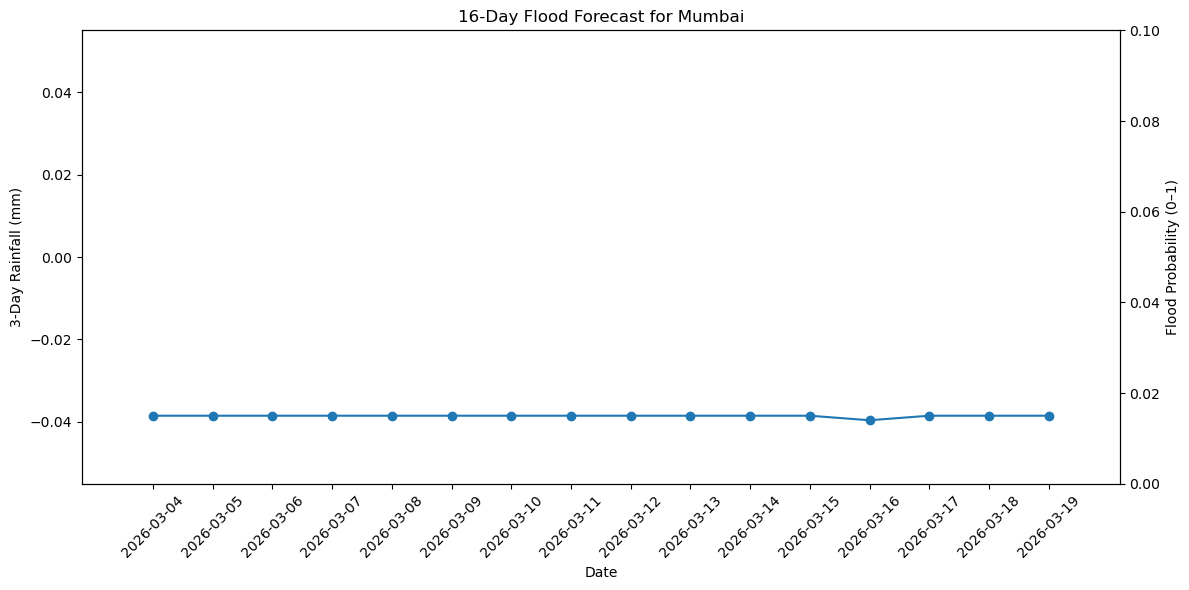

In [111]:
import matplotlib.pyplot as plt

if flood_results is None:
    print("Flood data not available — cannot plot.")
else:
    # Extract values
    dates = [day["date"] for day in flood_results]
    rain_3day = [day["rainfall_3day"] for day in flood_results]
    probabilities = [day["probability"] for day in flood_results]

    # Create figure
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Rainfall bars
    ax1.bar(dates, rain_3day)
    ax1.set_ylabel("3-Day Rainfall (mm)")
    ax1.set_xlabel("Date")
    ax1.set_xticks(dates)
    ax1.set_xticklabels(dates, rotation=45)

    # Probability line
    ax2 = ax1.twinx()
    ax2.plot(dates, probabilities, marker='o')
    ax2.set_ylabel("Flood Probability (0–1)")
    ax2.set_ylim(0, max(0.1, max(probabilities) * 1.2))

    plt.title(f"16-Day Flood Forecast for {place}")
    plt.tight_layout()
    plt.show()

In [112]:
# thunderstorm API

In [113]:
import requests
import pandas as pd

def get_thunder_api_data():

    lat, lon = place_coordinates[place]

    url = (
        f"https://api.open-meteo.com/v1/forecast"
        f"?latitude={lat}"
        f"&longitude={lon}"
        f"&daily=temperature_2m_max,precipitation_sum"
        f"&hourly=dewpoint_2m,surface_pressure,wind_speed_10m,cape"
        f"&forecast_days=16"
        f"&timezone=auto"
)

    response = requests.get(url)
    data = response.json()


    # Daily data
    daily_dates = data["daily"]["time"]
    daily_temp = data["daily"]["temperature_2m_max"]
    daily_rain = data["daily"]["precipitation_sum"]

    # Hourly data
    hourly_df = pd.DataFrame({
        "time": pd.to_datetime(data["hourly"]["time"]),
        "dewpoint": data["hourly"]["dewpoint_2m"],
        "pressure": data["hourly"]["surface_pressure"],
        "wind": data["hourly"]["wind_speed_10m"],
        "cape": data["hourly"]["cape"]
})

    hourly_df["date"] = hourly_df["time"].dt.date

    # Aggregations
    daily_dew = hourly_df.groupby("date")["dewpoint"].mean()
    daily_pressure = hourly_df.groupby("date")["pressure"].mean()
    daily_wind = hourly_df.groupby("date")["wind"].mean()
    daily_cape = hourly_df.groupby("date")["cape"].max()

    results = []

    for i, date in enumerate(daily_dates):
        d = pd.to_datetime(date).date()

        results.append({
            "date": date,
            "2m_temperature": daily_temp[i],
            "2m_dewpoint_temperature": daily_dew.get(d, 0),
            "surface_pressure": daily_pressure.get(d, 0),
            "10m_wind_speed": daily_wind.get(d, 0),
            "total_precipitation": daily_rain[i],
            "cape": daily_cape.get(d, 0)
        })

    return results

In [114]:
def predict_thunder_16day(threshold=0.4):

    api_data = get_thunder_api_data()

    results = []

    for day in api_data:

        features = pd.DataFrame([{
            "2m_temperature": day["2m_temperature"],
            "2m_dewpoint_temperature": day["2m_dewpoint_temperature"],
            "surface_pressure": day["surface_pressure"],
            "10m_wind_speed": day["10m_wind_speed"],
            "total_precipitation": day["total_precipitation"],
            "cape": day["cape"]
        }])

        prob = thunder_model.predict_proba(features)[0][1]
        label = 1 if prob >= threshold else 0

        def thunder_level(prob):
            if prob >= 0.65:
                return "HIGH"
            elif prob >= 0.40:
                return "MODERATE"
            elif prob >= 0.20:
                return "LOW"
            else:
                return "VERY LOW"

        temp = day["2m_temperature"] if day["2m_temperature"] is not None else 0.0
        dew = day["2m_dewpoint_temperature"] if day["2m_dewpoint_temperature"] is not None else 0.0
        pressure = day["surface_pressure"] if day["surface_pressure"] is not None else 0.0
        wind = day["10m_wind_speed"] if day["10m_wind_speed"] is not None else 0.0
        rain = day["total_precipitation"] if day["total_precipitation"] is not None else 0.0
        cape = day["cape"] if day["cape"] is not None else 0.0
        

        results.append({
            "date": day["date"],
            "temperature": round(temp, 1),
            "dewpoint": round(dew, 1),
            "pressure": round(pressure, 1),
            "wind_speed": round(wind, 1),
            "rainfall": round(rain, 1),
            "cape": round(cape, 1),
            "probability": round(float(prob), 3),
            "level": thunder_level(prob)
        })

    return results

In [115]:
thunder_results = predict_thunder_16day()

for day in thunder_results:
    print(
        f"{day['date']} | "
        f"CAPE:{day['cape']} | "
        f"Rain:{day['rainfall']}mm | "
        f"Temperature:{day["temperature"]}°C | "
        f"dew_point:{day["dewpoint"]}°C |"
        f"surface_pressure:{day["pressure"]}(hPa) |"
        f"wind_speed:{day["wind_speed"]}(km/h) |"
        f"Prob:{day['probability']} | "
        f"Risk:{day['level']}"
    )

2026-03-04 | CAPE:100.0 | Rain:0.0mm | Temperature:28.8°C | dew_point:21.3°C |surface_pressure:1010.5(hPa) |wind_speed:12.0(km/h) |Prob:0.003 | Risk:VERY LOW
2026-03-05 | CAPE:30.0 | Rain:0.0mm | Temperature:29.2°C | dew_point:21.0°C |surface_pressure:1009.8(hPa) |wind_speed:12.7(km/h) |Prob:0.009 | Risk:VERY LOW
2026-03-06 | CAPE:0.0 | Rain:0.0mm | Temperature:29.3°C | dew_point:19.3°C |surface_pressure:1008.8(hPa) |wind_speed:14.7(km/h) |Prob:0.0 | Risk:VERY LOW
2026-03-07 | CAPE:0.0 | Rain:0.0mm | Temperature:28.1°C | dew_point:21.2°C |surface_pressure:1009.2(hPa) |wind_speed:13.6(km/h) |Prob:0.01 | Risk:VERY LOW
2026-03-08 | CAPE:120.0 | Rain:0.0mm | Temperature:28.2°C | dew_point:22.4°C |surface_pressure:1009.2(hPa) |wind_speed:10.8(km/h) |Prob:0.015 | Risk:VERY LOW
2026-03-09 | CAPE:190.0 | Rain:0.0mm | Temperature:27.9°C | dew_point:22.7°C |surface_pressure:1009.3(hPa) |wind_speed:7.6(km/h) |Prob:0.028 | Risk:VERY LOW
2026-03-10 | CAPE:320.0 | Rain:0.0mm | Temperature:27.8°C | d

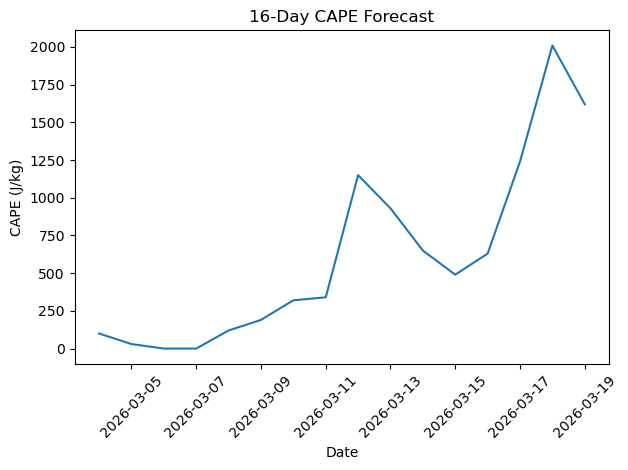

In [116]:
import matplotlib.pyplot as plt
from datetime import datetime

# Make sure thunder_results is already computed
# thunder_results = predict_thunder_16day()

dates = [datetime.strptime(day["date"], "%Y-%m-%d") for day in thunder_results]
cape_values = [day["cape"] for day in thunder_results]

plt.figure()
plt.plot(dates, cape_values)
plt.xlabel("Date")
plt.ylabel("CAPE (J/kg)")
plt.title("16-Day CAPE Forecast")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [117]:
#wind api

In [118]:
import requests
import numpy as np
from datetime import datetime

def get_wind_api_data(place):

    if place not in place_coordinates:
        raise ValueError("Place not found in coordinates dictionary")

    lat, lon = place_coordinates[place]

    url = (
        f"https://api.open-meteo.com/v1/forecast"
        f"?latitude={lat}"
        f"&longitude={lon}"
        f"&daily=wind_speed_10m_max,temperature_2m_max,relative_humidity_2m_mean"
        f"&forecast_days=16"
        f"&timezone=auto"
    )

    response = requests.get(url)
    data = response.json()

    if "daily" not in data:
        raise ValueError(f"API Error: {data}")

    daily = data["daily"]

    wind_raw = daily["wind_speed_10m_max"]

    wind_clean = []
    for w in wind_raw:
        if w is None:
            wind_clean.append(0.0)
        else:
            wind_clean.append(float(w))

    return {
        "dates": daily["time"],
        "wind": wind_clean,
        "temp": daily["temperature_2m_max"],
        "humidity": daily["relative_humidity_2m_mean"]
    }

In [119]:
def adjust_wind_probability(base_prob,
                            wind_api, hist_wind,
                            wind3_api, hist_3day,
                            temp_api, hist_temp,
                            humidity_api, hist_humidity):

    # Wind ratio
    wind_ratio = wind_api / hist_wind if hist_wind > 0 else 1

    if wind_ratio > 1.3:
        wind_adj = 0.08
    elif wind_ratio > 1.1:
        wind_adj = 0.04
    elif wind_ratio < 0.8:
        wind_adj = -0.05
    else:
        wind_adj = 0

    # 3-Day Wind Ratio
    ratio_3day = wind3_api / hist_3day if hist_3day > 0 else 1

    if ratio_3day > 1.3:
        wind3_adj = 0.10
    elif ratio_3day > 1.1:
        wind3_adj = 0.05
    else:
        wind3_adj = 0

    # Temperature deviation
    temp_diff = temp_api - hist_temp

    if temp_diff > 3:
        temp_adj = 0.03
    elif temp_diff < -3:
        temp_adj = -0.02
    else:
        temp_adj = 0

    # Humidity deviation
    humidity_diff = humidity_api - hist_humidity

    if humidity_diff > 10:
        humidity_adj = 0.04
    elif humidity_diff < -10:
        humidity_adj = -0.03
    else:
        humidity_adj = 0

    new_prob = base_prob + wind_adj + wind3_adj + temp_adj + humidity_adj

    return max(0, min(new_prob, 1))

In [120]:
def wind_level(prob):
    if prob >= 0.65:
        return "HIGH"
    elif prob >= 0.40:
        return "MODERATE"
    elif prob >= 0.20:
        return "LOW"
    else:
        return "VERY LOW"

In [121]:
from datetime import datetime
import numpy as np

def predict_wind_16day(place):

    # Stop if place not in historical wind dataset
    if place not in df_wind["place"].unique():
        print(f"Windstorm data not available for {place}")
        return None

    # Get API data
    api_data = get_wind_api_data(place)

    if api_data is None:
        return None

    dates = api_data["dates"]

    # Sanitize API numeric values (remove None safely)
    wind_daily = [float(x) if x is not None else 0.0 for x in api_data["wind"]]
    temp_daily = [float(x) if x is not None else 0.0 for x in api_data["temp"]]
    humidity_daily = [float(x) if x is not None else 0.0 for x in api_data["humidity"]]

    results = []

    # --- Calculate 3-day cumulative wind ---
    wind_3day = []
    for i in range(len(wind_daily)):
        if i == 0:
            wind_3day.append(wind_daily[i])
        elif i == 1:
            wind_3day.append(wind_daily[i] + wind_daily[i-1])
        else:
            wind_3day.append(
                wind_daily[i] +
                wind_daily[i-1] +
                wind_daily[i-2]
            )

    # --- Loop through forecast days ---
    for i in range(len(dates)):

        date = dates[i]
        month = datetime.strptime(date, "%Y-%m-%d").month

        # Monthly base probability
        monthly_result = predict_windstorm_monthly(place, month)

        if monthly_result is None:
            continue

        base_prob = monthly_result["probability"]

        # Historical baseline
        place_data = df_wind[
            (df_wind["place"] == place) &
            (df_wind["month"] == month)
        ]

        # Skip if no historical data
        if place_data.empty:
            continue

        hist_wind = place_data["WindSpeed_km_per_hr"].mean()
        hist_temp = place_data["Temperature_C"].mean()
        hist_humidity = place_data["Humidity_percent"].mean()
        hist_wind3 = place_data["WindSpeed_3day_cum"].mean()

        # Skip if baseline becomes NaN
        if any(np.isnan(x) for x in [hist_wind, hist_temp, hist_humidity, hist_wind3]):
            continue

        # API values for today
        wind_today = wind_daily[i]
        temp_today = temp_daily[i]
        humidity_today = humidity_daily[i]
        wind3_today = wind_3day[i]

        prob = base_prob

        # Wind deviation
        if wind_today > hist_wind * 1.2:
            prob += 0.05

        # 3-day wind deviation
        if wind3_today > hist_wind3 * 1.2:
            prob += 0.05

        # Temperature deviation
        if temp_today > hist_temp + 3:
            prob += 0.03

        # Humidity deviation
        if humidity_today > hist_humidity + 10:
            prob += 0.03

        prob = max(0, min(prob, 1))

        results.append({
            "date": date,
            "wind_speed": round(wind_today, 1),
            "wind_3day": round(wind3_today, 1),
            "temperature": round(temp_today, 1),
            "humidity": round(humidity_today, 1),
            "probability": round(prob, 3),
            "level": wind_level(prob)
        })

    return results

In [122]:
wind_results = predict_wind_16day(place)

if wind_results is None:
    print("Windstorm : Not Applicable")
else:
    for day in wind_results:
        print(
            f"{day['date']} | "
            f"Wind: {day['wind_speed']} km/h | "
            f"3-Day: {day['wind_3day']} | "
            f"Temp: {day['temperature']}°C | "
            f"Humidity: {day['humidity']}% | "
            f"Prob: {day['probability']} | "
            f"Risk: {day['level']}"
        )

2026-03-04 | Wind: 18.2 km/h | 3-Day: 18.2 | Temp: 28.8°C | Humidity: 67.0% | Prob: 0.27 | Risk: LOW
2026-03-05 | Wind: 19.5 km/h | 3-Day: 37.7 | Temp: 29.2°C | Humidity: 65.0% | Prob: 0.27 | Risk: LOW
2026-03-06 | Wind: 22.2 km/h | 3-Day: 59.9 | Temp: 29.3°C | Humidity: 58.0% | Prob: 0.27 | Risk: LOW
2026-03-07 | Wind: 19.5 km/h | 3-Day: 61.2 | Temp: 28.1°C | Humidity: 69.0% | Prob: 0.27 | Risk: LOW
2026-03-08 | Wind: 18.7 km/h | 3-Day: 60.4 | Temp: 28.2°C | Humidity: 74.0% | Prob: 0.27 | Risk: LOW
2026-03-09 | Wind: 13.9 km/h | 3-Day: 52.1 | Temp: 27.9°C | Humidity: 76.0% | Prob: 0.27 | Risk: LOW
2026-03-10 | Wind: 12.4 km/h | 3-Day: 45.0 | Temp: 27.8°C | Humidity: 81.0% | Prob: 0.27 | Risk: LOW
2026-03-11 | Wind: 13.5 km/h | 3-Day: 39.8 | Temp: 30.6°C | Humidity: 72.0% | Prob: 0.27 | Risk: LOW
2026-03-12 | Wind: 18.7 km/h | 3-Day: 44.6 | Temp: 32.3°C | Humidity: 59.0% | Prob: 0.3 | Risk: LOW
2026-03-13 | Wind: 18.0 km/h | 3-Day: 50.2 | Temp: 31.2°C | Humidity: 62.0% | Prob: 0.27 | R

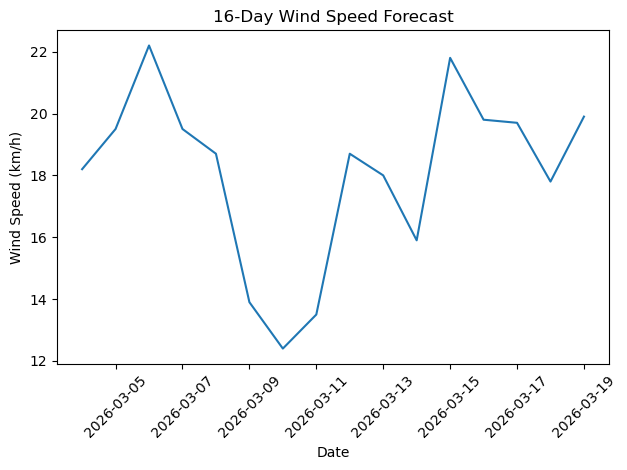

In [123]:
import matplotlib.pyplot as plt
from datetime import datetime

if wind_results is None:
    print("Windstorm data not available — cannot plot.")
else:
    dates = [datetime.strptime(day["date"], "%Y-%m-%d") for day in wind_results]
    wind_values = [day["wind_speed"] for day in wind_results]

    plt.figure()
    plt.plot(dates, wind_values)
    plt.xlabel("Date")
    plt.ylabel("Wind Speed (km/h)")
    plt.title("16-Day Wind Speed Forecast")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [124]:
from datetime import datetime, timedelta

def integrate_16day_forecast(place):

    # --- Get all disaster results ---
    landslide_results = daily_results if 'daily_results' in globals() else None
    flood_results = predict_flood_16day(place)
    wind_results = predict_wind_16day(place)
    thunder_results = predict_thunder_16day()

    today = datetime.today()

    final_output = {
        "place": place,
        "forecast_days": 16,
        "data": []
    }

    for i in range(16):

        date_str = (today + timedelta(days=i)).strftime("%Y-%m-%d")

        day_block = {
            "date": date_str,
            "disasters": {
                "landslide": None,
                "flood": None,
                "thunderstorm": None,
                "windstorm": None
            }
        }

        # ---------------- LANDSLIDE ----------------
        if landslide_results:
            match = next((d for d in landslide_results if d["date"] == date_str), None)
            if match and match["probability"] is not None:
                day_block["disasters"]["landslide"] = {
                    "probability": match["probability"],
                    "level": match["level"]
                }

        # ---------------- FLOOD ----------------
        if flood_results:
            match = next((d for d in flood_results if d["date"] == date_str), None)
            if match:
                day_block["disasters"]["flood"] = {
                    "probability": match["probability"],
                    "level": match["level"]
                }

        # ---------------- THUNDERSTORM ----------------
        if thunder_results:
            match = next((d for d in thunder_results if d["date"] == date_str), None)
            if match:
                day_block["disasters"]["thunderstorm"] = {
                    "probability": match["probability"],
                    "level": match["level"]
                }

        # ---------------- WINDSTORM ----------------
        if wind_results:
            match = next((d for d in wind_results if d["date"] == date_str), None)
            if match:
                day_block["disasters"]["windstorm"] = {
                    "probability": match["probability"],
                    "level": match["level"]
                }

        final_output["data"].append(day_block)

    return final_output

In [125]:
def show_16day_console(place):

    result = integrate_16day_forecast(place)

    for idx, day in enumerate(result["data"], 1):

        print("\n" + "="*40)
        print(f"📅 Day {idx}  ({day['date']})")
        print("="*40)

        for disaster, value in day["disasters"].items():

            label = disaster.capitalize()

            if value is None:
                print(f"{label:<15}: Not Applicable")
            else:
                pri nt(f"{label:<15}: {value['level']} ({value['probability']})")

In [126]:
show_16day_console(place)


📅 Day 1  (2026-03-04)
Landslide      : Not Applicable
Flood          : LOW (0.015)
Thunderstorm   : VERY LOW (0.003)
Windstorm      : LOW (0.27)

📅 Day 2  (2026-03-05)
Landslide      : Not Applicable
Flood          : LOW (0.015)
Thunderstorm   : VERY LOW (0.009)
Windstorm      : LOW (0.27)

📅 Day 3  (2026-03-06)
Landslide      : Not Applicable
Flood          : LOW (0.015)
Thunderstorm   : VERY LOW (0.0)
Windstorm      : LOW (0.27)

📅 Day 4  (2026-03-07)
Landslide      : Not Applicable
Flood          : LOW (0.015)
Thunderstorm   : VERY LOW (0.01)
Windstorm      : LOW (0.27)

📅 Day 5  (2026-03-08)
Landslide      : Not Applicable
Flood          : LOW (0.015)
Thunderstorm   : VERY LOW (0.015)
Windstorm      : LOW (0.27)

📅 Day 6  (2026-03-09)
Landslide      : Not Applicable
Flood          : LOW (0.015)
Thunderstorm   : VERY LOW (0.028)
Windstorm      : LOW (0.27)

📅 Day 7  (2026-03-10)
Landslide      : Not Applicable
Flood          : LOW (0.015)
Thunderstorm   : VERY LOW (0.032)
Windstorm

In [127]:
# import os
# import joblib

# os.makedirs("model", exist_ok=True)

# joblib.dump(flood_model, "model/flood.pkl")
# joblib.dump(wind_model, "model/wind.pkl")
# joblib.dump(thunder_model, "model/thunder.pkl")
# joblib.dump(model, "model/landslide.pkl")